   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.6 MB/s eta 0:00:00
Mounted at /content/drive


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Silver files: 3655
Non-silver files: 16129
Train size: 5118
Val size: 1462
Test size: 730


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Validation Results:
eval_loss: 0.8469
eval_model_preparation_time: 0.0033
eval_accuracy: 0.8714
eval_precision: 0.8615
eval_recall: 0.8851
eval_f1: 0.8731
eval_runtime: 1374.8464
eval_samples_per_second: 1.0630
eval_steps_per_second: 0.0670


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Confusion Matrix (threshold = 0.50):
[[329  36]
 [ 45 320]]

Classification Report (threshold = 0.50):
              precision    recall  f1-score   support

           0     0.8797    0.9014    0.8904       365
           1     0.8989    0.8767    0.8877       365

    accuracy                         0.8890       730
   macro avg     0.8893    0.8890    0.8890       730
weighted avg     0.8893    0.8890    0.8890       730

t=0.20 | F1=0.8898 | P=0.8838 | R=0.8959
t=0.21 | F1=0.8898 | P=0.8838 | R=0.8959
t=0.22 | F1=0.8883 | P=0.8835 | R=0.8932
t=0.23 | F1=0.8868 | P=0.8832 | R=0.8904
t=0.24 | F1=0.8865 | P=0.8852 | R=0.8877
t=0.25 | F1=0.8861 | P=0.8874 | R=0.8849
t=0.26 | F1=0.8861 | P=0.8874 | R=0.8849
t=0.27 | F1=0.8861 | P=0.8874 | R=0.8849
t=0.28 | F1=0.8874 | P=0.8898 | R=0.8849
t=0.29 | F1=0.8874 | P=0.8898 | R=0.8849
t=0.30 | F1=0.8874 | P=0.8898 | R=0.8849
t=0.31 | F1=0.8886 | P=0.8923 | R=0.8849
t=0.32 | F1=0.8886 | P=0.8923 | R=0.8849
t=0.33 | F1=0.8886 | P=0.8923 | R=0.

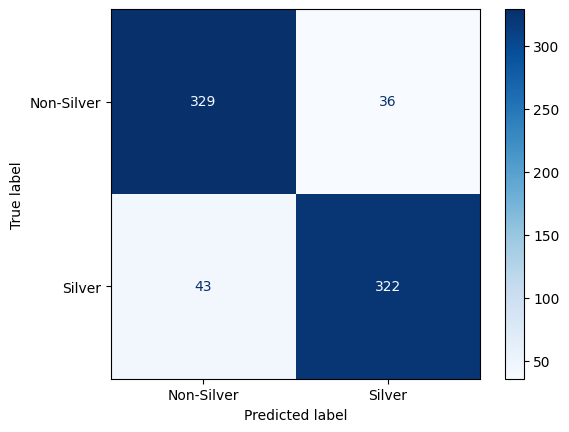

In [1]:
# =========================
# Install
# =========================
!pip install -q transformers accelerate evaluate pillow scikit-learn timm

# =========================
# Imports
# =========================
import os
import random
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
)

from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification,
    Trainer,
    TrainingArguments,
)

# =========================
# Google Drive
# =========================
drive.mount("/content/drive")

# =========================
# Paths
# =========================
silver_dir = "/content/drive/MyDrive/silver_detection/cleaned_dataset/silver_images"
nonsilver_dir = "/content/drive/MyDrive/silver_detection/cleaned_dataset/non_silver_images"

# other models
# MODEL_PATH = "/content/drive/MyDrive/silver_detection/models/resnet50"
# MODEL_PATH = "/content/drive/MyDrive/silver_detection/models/deit"
# MODEL_PATH = "/content/drive/MyDrive/silver_detection/models/efficientbet_b0"
# MODEL_PATH = "/content/drive/MyDrive/silver_detection/models/densenet_121"

# folder where you saved model + processor
MODEL_PATH = "/content/drive/MyDrive/silver_detection/models/vitb16"

SEED = 42
VAL_SPLIT = 0.2
TEST_SPLIT = 0.1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# =========================
# Load saved processor + model
# =========================
image_processor = AutoImageProcessor.from_pretrained(MODEL_PATH, use_fast=True)
model = AutoModelForImageClassification.from_pretrained(MODEL_PATH)

# =========================
# File lists
# =========================
silver_files = [
    f for f in os.listdir(silver_dir)
    if os.path.isfile(os.path.join(silver_dir, f))
]

nonsilver_files = [
    f for f in os.listdir(nonsilver_dir)
    if os.path.isfile(os.path.join(nonsilver_dir, f))
]

print("Silver files:", len(silver_files))
print("Non-silver files:", len(nonsilver_files))

# =========================
# Sample equal non-silver
# =========================
sampled_nonsilver_files = random.sample(nonsilver_files, len(silver_files))

silver_paths = [os.path.join(silver_dir, f) for f in silver_files]
nonsilver_paths = [os.path.join(nonsilver_dir, f) for f in sampled_nonsilver_files]

random.shuffle(silver_paths)
random.shuffle(nonsilver_paths)

# =========================
# Split each class separately
# =========================
n_per_class = len(silver_paths)

test_count = int(n_per_class * TEST_SPLIT)
val_count = int(n_per_class * VAL_SPLIT)

silver_test = silver_paths[:test_count]
silver_val = silver_paths[test_count:test_count + val_count]
silver_train = silver_paths[test_count + val_count:]

nonsilver_test = nonsilver_paths[:test_count]
nonsilver_val = nonsilver_paths[test_count:test_count + val_count]
nonsilver_train = nonsilver_paths[test_count + val_count:]

# =========================
# Combine splits
# =========================
train_paths = silver_train + nonsilver_train
train_labels = [1] * len(silver_train) + [0] * len(nonsilver_train)

val_paths = silver_val + nonsilver_val
val_labels = [1] * len(silver_val) + [0] * len(nonsilver_val)

test_paths = silver_test + nonsilver_test
test_labels = [1] * len(silver_test) + [0] * len(nonsilver_test)

# =========================
# Shuffle within each split
# =========================
train_combined = list(zip(train_paths, train_labels))
val_combined = list(zip(val_paths, val_labels))
test_combined = list(zip(test_paths, test_labels))

random.shuffle(train_combined)
random.shuffle(val_combined)
random.shuffle(test_combined)

train_paths, train_labels = zip(*train_combined)
val_paths, val_labels = zip(*val_combined)
test_paths, test_labels = zip(*test_combined)

train_paths, train_labels = list(train_paths), list(train_labels)
val_paths, val_labels = list(val_paths), list(val_labels)
test_paths, test_labels = list(test_paths), list(test_labels)

print("Train size:", len(train_paths))
print("Val size:", len(val_paths))
print("Test size:", len(test_paths))

# =========================
# Dataset
# =========================
class SilverDataset(Dataset):
    def __init__(self, paths, labels, processor):
        self.paths = paths
        self.labels = labels
        self.processor = processor

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        label = self.labels[idx]

        image = Image.open(path).convert("RGB")
        encoded = self.processor(images=image, return_tensors="pt")

        return {
            "pixel_values": encoded["pixel_values"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }

val_ds = SilverDataset(val_paths, val_labels, image_processor)
test_ds = SilverDataset(test_paths, test_labels, image_processor)

# =========================
# Metrics
# =========================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    p = precision_score(labels, preds, zero_division=0)
    r = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)

    return {
        "accuracy": acc,
        "precision": p,
        "recall": r,
        "f1": f1,
    }

# =========================
# Eval-only Trainer
# =========================
eval_args = TrainingArguments(
    output_dir="./vit_eval_output",
    remove_unused_columns=False,
    per_device_eval_batch_size=16,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=eval_args,
    compute_metrics=compute_metrics,
)

# =========================
# Validation results
# =========================
val_results = trainer.evaluate(eval_dataset=val_ds)
print("\nValidation Results:")
for k, v in val_results.items():
    if isinstance(v, (int, float)):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

# =========================
# Test prediction
# =========================
pred_output = trainer.predict(test_ds)
logits = pred_output.predictions
y_true = pred_output.label_ids

probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]

# =========================
# Classification report at threshold 0.5
# =========================
y_pred = (probs > 0.5).astype(int)

print("\nConfusion Matrix (threshold = 0.50):")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report (threshold = 0.50):")
print(classification_report(y_true, y_pred, digits=4))

# =========================
# Threshold tuning
# =========================
best_t, best_f1 = 0.5, 0.0

for t in np.arange(0.20, 0.70, 0.01):
    preds = (probs > t).astype(int)

    f1 = f1_score(y_true, preds, zero_division=0)
    p = precision_score(y_true, preds, zero_division=0)
    r = recall_score(y_true, preds, zero_division=0)

    print(f"t={t:.2f} | F1={f1:.4f} | P={p:.4f} | R={r:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"\nBest threshold: {best_t:.2f} | Best F1: {best_f1:.4f}")

y_pred_best = (probs > best_t).astype(int)

print("\nConfusion Matrix (best threshold):")
print(confusion_matrix(y_true, y_pred_best))

print("\nClassification Report (best threshold):")
print(classification_report(y_true, y_pred_best, digits=4))

# =========================
# Plot confusion matrix
# =========================
disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred_best,
    display_labels=["Non-Silver", "Silver"],
    cmap="Blues",
    values_format="d"
)